In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("", sep=None, engine="python")

y = df["is_alarm"]
X = df.drop(["is_alarm"], axis=1)

X = X.select_dtypes(include=[np.number])  

data = pd.concat([X, y], axis=1).dropna()
X = data.drop("is_alarm", axis=1)
y = data["is_alarm"]

In [3]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
y_resampled = y_resampled.astype(int)

print("SMOTE:")
print(y_resampled.value_counts())

SMOTE:
is_alarm
0    20980
1    20980
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
param_dist = {
    'n_neighbors': [3, 5, 7, 9], 
    'weights': ['uniform', 'distance'], 
    'p': [1, 2] 
}

knn_random = RandomizedSearchCV(
    KNeighborsClassifier(), 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=3, 
    scoring='accuracy', 
    random_state=42, 
    n_jobs=-1 
)

knn_random.fit(X_train_scaled, y_train)

best_knn = knn_random.best_estimator_

print("Найкращі знайдені параметри:", knn_random.best_params_)

Найкращі знайдені параметри: {'weights': 'distance', 'p': 1, 'n_neighbors': 3}


(Best KNN:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4120
           1       1.00      0.91      0.95      4272

    accuracy                           0.96      8392
   macro avg       0.96      0.96      0.96      8392
weighted avg       0.96      0.96      0.96      8392


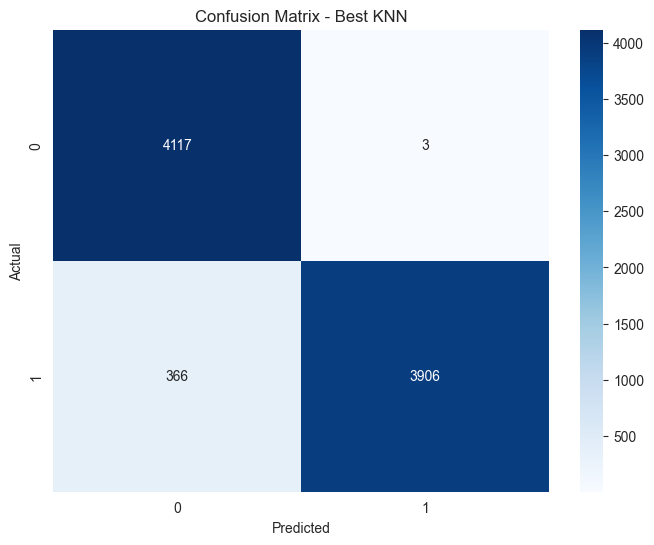

In [6]:
y_pred_knn = best_knn.predict(X_test_scaled)

print("(Best KNN:")
print(classification_report(y_test, y_pred_knn))

conf_mat_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat_knn, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best KNN")
plt.show()

In [7]:
import pickle

with open("knn_best_model.pkl", "wb") as f:
    pickle.dump(best_knn, f)

print("Model saved as knn_best_model.pkl")

Model saved as knn_best_model.pkl


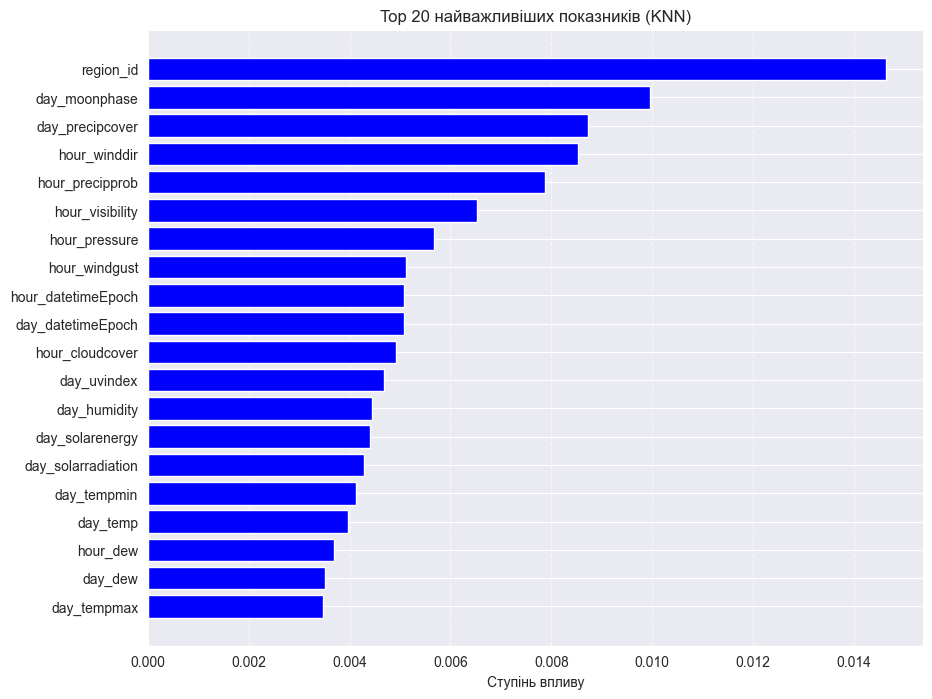

In [8]:
sample_idx = np.random.choice(X_test_scaled.shape[0], 5000, replace=False)
X_test_sample = X_test_scaled[sample_idx]
y_test_sample = y_test.iloc[sample_idx] if isinstance(y_test, pd.Series) else y_test[sample_idx]

result = permutation_importance(best_knn, X_test_sample, y_test_sample, n_repeats=5, random_state=42, n_jobs=-1)

importance_df_knn = pd.DataFrame({'Feature': X.columns, 'Importance': result.importances_mean})
top_20_knn = importance_df_knn.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_20_knn['Feature'][::-1], top_20_knn['Importance'][::-1], color='blue')
plt.title('Top 20 найважливіших показників (KNN)')
plt.xlabel('Ступінь впливу')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()